In [1]:
# ============================================================
# CELL 1: Install & HuggingFace Login
# ============================================================
!pip install -q "ray[tune]" optuna torch nltk pandas matplotlib seaborn tqdm scikit-learn huggingface_hub accelerate

from huggingface_hub import login
import getpass
login(token=getpass.getpass("🔑 HuggingFace token: "))
print("✅ Ready")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.7 MB/s eta 0:00:00


🔑 HuggingFace token:  ········


✅ Ready


Device: cuda
Total pairs: 13186
                                        en  \
0                       Muiriel is 20 now.   
1                       Muiriel is 20 now.   
2  Education in this world disappoints me.   

                                            hi  
0             म्यूरियल अब बीस साल की हो गई है।  
1                   म्यूरियल अब बीस साल की है।  
2  मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।  
EN vocab: 4117  |  HI vocab: 4044


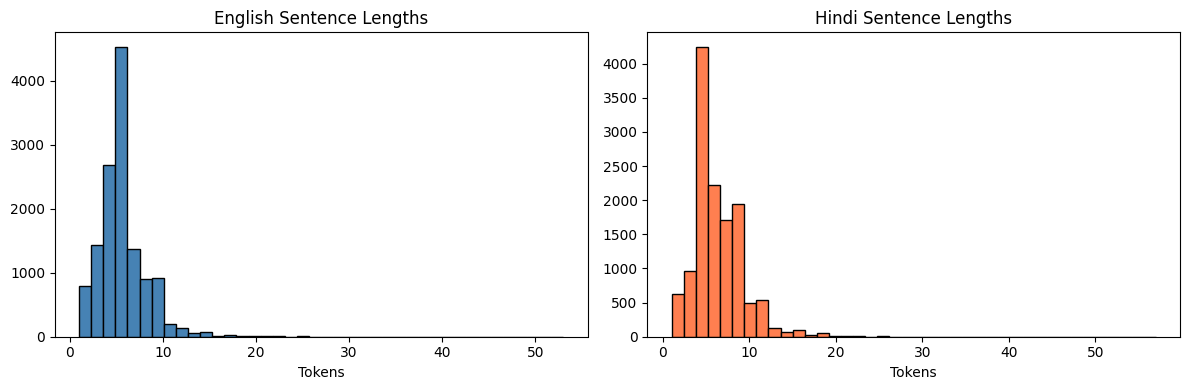

In [2]:
# ============================================================
# CELL 2: Imports, Data, Vocabulary, Dataset, EDA
# ============================================================
import os, gc, math, time, warnings, json, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 50
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3
print(f"Device: {DEVICE}")

# ── Load dataset ──────────────────────────────────────────
# Upload English-Hindi.tsv from the Drive link in the assignment first
df = pd.read_csv('/kaggle/input/datasets/saumyapancholi/english-hindi/English-Hindi.tsv', sep='\t', header=None,
                 names=['id1','en','id2','hi'])
df = df[['en','hi']].dropna().reset_index(drop=True)
print(f"Total pairs: {len(df)}")
print(df.head(3))

# ── Vocabulary ────────────────────────────────────────────
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.itos = {0:'<pad>', 1:'<sos>', 2:'<eos>', 3:'<unk>'}
        self.stoi = {v:k for k,v in self.itos.items()}
        self.freq_threshold = freq_threshold
        self.idx = 4

    def build_vocab(self, sentences):
        freq = Counter()
        for s in sentences:
            freq.update(s.lower().strip().split())
        for w, f in freq.items():
            if f >= self.freq_threshold:
                self.stoi[w] = self.idx
                self.itos[self.idx] = w
                self.idx += 1

    def encode(self, sentence, maxlen=MAX_LEN):
        toks = sentence.lower().strip().split()[:maxlen-2]
        ids  = [SOS_IDX] + [self.stoi.get(t, UNK_IDX) for t in toks] + [EOS_IDX]
        ids += [PAD_IDX] * (maxlen - len(ids))
        return ids[:maxlen]

    def decode(self, ids):
        out = []
        for i in ids:
            if i == EOS_IDX: break
            if i not in (PAD_IDX, SOS_IDX):
                out.append(self.itos.get(i, '<unk>'))
        return ' '.join(out)

    def __len__(self): return self.idx

en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)
en_vocab.build_vocab(df['en'].tolist())
hi_vocab.build_vocab(df['hi'].tolist())
SRC_VOCAB = len(en_vocab)
TGT_VOCAB = len(hi_vocab)
print(f"EN vocab: {SRC_VOCAB}  |  HI vocab: {TGT_VOCAB}")

# ── Dataset ───────────────────────────────────────────────
class TranslationDataset(Dataset):
    def __init__(self, df, ev, hv):
        self.src = [ev.encode(s) for s in df['en']]
        self.tgt = [hv.encode(s) for s in df['hi']]

    def __len__(self): return len(self.src)

    def __getitem__(self, idx):
        s = torch.tensor(self.src[idx], dtype=torch.long)
        t = torch.tensor(self.tgt[idx], dtype=torch.long)
        return s, t[:-1], t[1:]

full_ds = TranslationDataset(df, en_vocab, hi_vocab)

def make_loader(batch_size, shuffle=True):
    return DataLoader(full_ds, batch_size=batch_size,
                      shuffle=shuffle, num_workers=0, drop_last=False)

# ── EDA plots ─────────────────────────────────────────────
df['en_len'] = df['en'].apply(lambda x: len(x.split()))
df['hi_len'] = df['hi'].apply(lambda x: len(x.split()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['en_len'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('English Sentence Lengths'); axes[0].set_xlabel('Tokens')
axes[1].hist(df['hi_len'], bins=40, color='coral',     edgecolor='black')
axes[1].set_title('Hindi Sentence Lengths');   axes[1].set_xlabel('Tokens')
plt.tight_layout()
plt.savefig('eda_lengths.png', dpi=120)
plt.show()



In [3]:
# ============================================================
# CELL 3: Full Transformer Architecture
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, maxlen=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(maxlen, d_model)
        pos = torch.arange(0, maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.dk   = d_model // num_heads
        self.nh   = num_heads
        self.Wq   = nn.Linear(d_model, d_model)
        self.Wk   = nn.Linear(d_model, d_model)
        self.Wv   = nn.Linear(d_model, d_model)
        self.Wo   = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
        self.last_attn = None

    def forward(self, q, k, v, mask=None):
        B  = q.size(0)
        Q  = self.Wq(q).view(B, -1, self.nh, self.dk).transpose(1, 2)
        K  = self.Wk(k).view(B, -1, self.nh, self.dk).transpose(1, 2)
        V  = self.Wv(v).view(B, -1, self.nh, self.dk).transpose(1, 2)
        sc = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.dk)
        if mask is not None:
            sc = sc.masked_fill(mask == 0, -1e9)
        attn           = self.drop(torch.softmax(sc, dim=-1))
        self.last_attn = attn.detach()
        out = torch.matmul(attn, V).transpose(1, 2).contiguous()
        return self.Wo(out.view(B, -1, self.nh * self.dk))


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model))

    def forward(self, x): return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn   = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.drop(self.attn(x, x, x, mask)))
        return self.norm2(x + self.drop(self.ffn(x)))


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, enc, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.drop(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.drop(self.cross_attn(x, enc, enc, src_mask)))
        return self.norm3(x + self.drop(self.ffn(x)))


class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=256, num_heads=8,
                 num_enc_layers=3, num_dec_layers=3, d_ff=512,
                 dropout=0.1, maxlen=MAX_LEN):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab, d_model, padding_idx=PAD_IDX)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD_IDX)
        self.pos     = PositionalEncoding(d_model, maxlen, dropout)
        self.enc     = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout)
                                      for _ in range(num_enc_layers)])
        self.dec     = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout)
                                      for _ in range(num_dec_layers)])
        self.fc      = nn.Linear(d_model, tgt_vocab)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def _src_mask(self, src):
        return (src != PAD_IDX).unsqueeze(1).unsqueeze(2)

    def _tgt_mask(self, tgt):
        B, T = tgt.shape
        pm   = (tgt != PAD_IDX).unsqueeze(1).unsqueeze(2)
        cm   = torch.tril(torch.ones(T, T, device=tgt.device)).bool().unsqueeze(0).unsqueeze(0)
        return pm & cm

    def forward(self, src, tgt):
        sm = self._src_mask(src)
        tm = self._tgt_mask(tgt)
        x  = self.pos(self.src_emb(src) * math.sqrt(self.d_model))
        for layer in self.enc: x = layer(x, sm)
        y  = self.pos(self.tgt_emb(tgt) * math.sqrt(self.d_model))
        for layer in self.dec: y = layer(y, x, sm, tm)
        return self.fc(y)

print("✅ Architecture ready")


✅ Architecture ready


▶  BASELINE (100 epochs)
  [Baseline] Epoch   1/100  Loss: 5.6066
  [Baseline] Epoch  10/100  Loss: 2.1062
  [Baseline] Epoch  20/100  Loss: 0.8793
  [Baseline] Epoch  30/100  Loss: 0.4329
  [Baseline] Epoch  40/100  Loss: 0.2873
  [Baseline] Epoch  50/100  Loss: 0.2317
  [Baseline] Epoch  60/100  Loss: 0.1992
  [Baseline] Epoch  70/100  Loss: 0.1811
  [Baseline] Epoch  80/100  Loss: 0.1644
  [Baseline] Epoch  90/100  Loss: 0.1584
  [Baseline] Epoch 100/100  Loss: 0.1484

  ✅ Loss  : 0.1484
  ✅ BLEU  : 0.5123
  ✅ Time  : 17.9 min


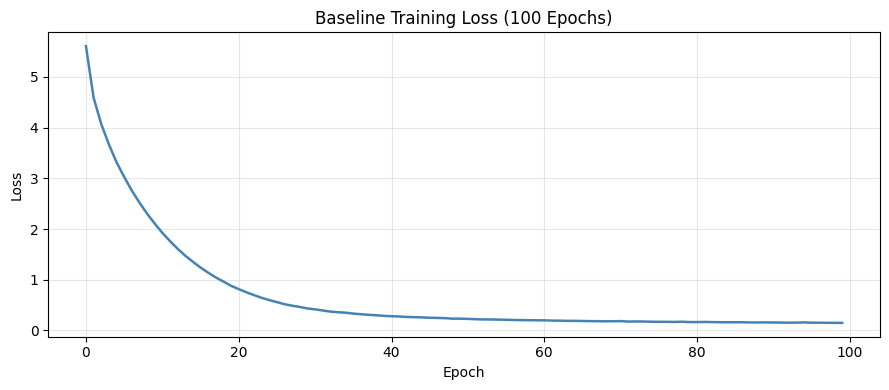

✅ GPU cache cleared


In [4]:
# ============================================================
# CELL 4: Baseline — 100 epochs, original hyperparams
# ============================================================
BASE_CONFIG = dict(d_model=256, num_heads=8, num_enc_layers=3,
                   num_dec_layers=3, d_ff=512, dropout=0.1,
                   lr=3e-4, batch_size=64)
BASE_EPOCHS = 100

def compute_bleu(model, loader, max_batches=30):
    model.eval()
    refs, hyps = [], []
    smooth = SmoothingFunction().method1
    with torch.no_grad():
        for i, (src, tgt_in, tgt_out) in enumerate(loader):
            if i >= max_batches: break
            src = src.to(DEVICE)
            B   = src.size(0)
            gen = torch.full((B, 1), SOS_IDX, dtype=torch.long, device=DEVICE)
            for _ in range(MAX_LEN - 1):
                nxt = model(src, gen)[:, -1, :].argmax(-1, keepdim=True)
                gen = torch.cat([gen, nxt], dim=1)
            for b in range(B):
                ref = [hi_vocab.itos.get(t.item(), '<unk>') for t in tgt_out[b]
                       if t.item() not in (PAD_IDX, EOS_IDX)]
                hyp = [hi_vocab.itos.get(t.item(), '<unk>') for t in gen[b, 1:]
                       if t.item() not in (PAD_IDX, EOS_IDX, SOS_IDX)]
                refs.append([ref]); hyps.append(hyp)
    return corpus_bleu(refs, hyps, smoothing_function=smooth)

def run_training(cfg, epochs, tag="Train"):
    loader    = make_loader(cfg['batch_size'])
    model     = Transformer(SRC_VOCAB, TGT_VOCAB,
                            d_model=cfg['d_model'],
                            num_heads=cfg['num_heads'],
                            num_enc_layers=cfg['num_enc_layers'],
                            num_dec_layers=cfg['num_dec_layers'],
                            d_ff=cfg['d_ff'],
                            dropout=cfg['dropout']).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'],
                           betas=(0.9, 0.98), eps=1e-9)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    losses    = []
    t0        = time.time()
    for epoch in range(1, epochs + 1):
        model.train(); total, n = 0.0, 0
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(src, tgt_in).reshape(-1, TGT_VOCAB),
                             tgt_out.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item(); n += 1
        el = total / n
        losses.append(el)
        scheduler.step(el)
        if epoch % 10 == 0 or epoch == 1:
            print(f"  [{tag}] Epoch {epoch:3d}/{epochs}  Loss: {el:.4f}")
        if epoch % 10 == 0:
            torch.cuda.empty_cache(); gc.collect()
    return model, losses, time.time() - t0

print("=" * 55)
print("▶  BASELINE (100 epochs)")
print("=" * 55)
baseline_model, baseline_losses, baseline_time = run_training(
    BASE_CONFIG, BASE_EPOCHS, "Baseline")

baseline_bleu = compute_bleu(baseline_model, make_loader(64, shuffle=False))

print("\n" + "=" * 55)
print(f"  ✅ Loss  : {baseline_losses[-1]:.4f}")
print(f"  ✅ BLEU  : {baseline_bleu:.4f}")
print(f"  ✅ Time  : {baseline_time/60:.1f} min")
print("=" * 55)

torch.save(baseline_model.state_dict(), 'transformer_translation_final.pth')

plt.figure(figsize=(9, 4))
plt.plot(baseline_losses, color='steelblue', lw=1.8)
plt.title('Baseline Training Loss (100 Epochs)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('baseline_loss_curve.png', dpi=120); plt.show()

del baseline_model
torch.cuda.empty_cache(); gc.collect()
print("✅ GPU cache cleared")


In [10]:
# ============================================================
# CELL 5: Pure Optuna 
# ============================================================
import gc
import optuna
from optuna.pruners  import SuccessiveHalvingPruner
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

MAX_TUNE_EPOCHS = 20    
NUM_SAMPLES     = 15   
TUNE_SUBSET     = 5000  

# ── Small dataset just for tuning ────────────────────────
tune_ds     = TranslationDataset(df.sample(TUNE_SUBSET, random_state=42).reset_index(drop=True),
                                  en_vocab, hi_vocab)

def make_tune_loader(batch_size):
    return DataLoader(tune_ds, batch_size=batch_size,
                      shuffle=True, num_workers=0, drop_last=False)

def objective(trial):
    lr               = trial.suggest_float("lr",    1e-5, 1e-3, log=True)
    batch_size       = trial.suggest_categorical("batch_size",       [32, 64, 128])
    num_heads        = trial.suggest_categorical("num_heads",        [4, 8])
    d_model_per_head = trial.suggest_categorical("d_model_per_head", [32, 64])
    d_ff             = trial.suggest_categorical("d_ff",             [512, 1024, 2048])
    dropout          = trial.suggest_float("dropout",      0.05, 0.4)
    num_enc_layers   = trial.suggest_categorical("num_enc_layers",   [2, 3, 4])

    d_model = num_heads * d_model_per_head
    loader  = make_tune_loader(batch_size)

    model = Transformer(
        SRC_VOCAB, TGT_VOCAB,
        d_model        = d_model,
        num_heads      = num_heads,
        num_enc_layers = num_enc_layers,
        num_dec_layers = 3,
        d_ff           = d_ff,
        dropout        = dropout,
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.98), eps=1e-9)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_TUNE_EPOCHS)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    epoch_loss = float('inf')

    for epoch in range(MAX_TUNE_EPOCHS):
        model.train()
        total, n = 0.0, 0
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(src, tgt_in).reshape(-1, TGT_VOCAB),
                             tgt_out.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item(); n += 1

        scheduler.step()
        epoch_loss = total / n

        trial.report(epoch_loss, epoch)
        if trial.should_prune():
            del model, optimizer, criterion
            torch.cuda.empty_cache(); gc.collect()
            raise optuna.exceptions.TrialPruned()

        if (epoch + 1) % 5 == 0:
            torch.cuda.empty_cache(); gc.collect()

    del model, optimizer, criterion
    torch.cuda.empty_cache(); gc.collect()
    return epoch_loss

# ── Study ─────────────────────────────────────────────────
study = optuna.create_study(
    direction = "minimize",
    sampler   = TPESampler(seed=42),
    pruner    = SuccessiveHalvingPruner(
        min_resource            = 3,
        reduction_factor        = 2,
        min_early_stopping_rate = 0,
    ),
)

print("=" * 55)
print(f"▶  TUNING: {NUM_SAMPLES} trials × max {MAX_TUNE_EPOCHS} epochs")
print(f"   Subset : {TUNE_SUBSET} pairs (fast search)")
print("=" * 55)

completed, pruned = 0, 0
for i in range(NUM_SAMPLES):
    try:
        trial     = study.ask()
        loss      = objective(trial)
        study.tell(trial, loss)
        completed += 1
        print(f"  Trial {i+1:2d}/{NUM_SAMPLES}  "
              f"Loss={loss:.4f}  "
              f"lr={trial.params['lr']:.2e}  "
              f"d_model={trial.params['num_heads']*trial.params['d_model_per_head']}  "
              f"d_ff={trial.params['d_ff']}")
    except optuna.exceptions.TrialPruned:
        study.tell(trial, state=optuna.trial.TrialState.PRUNED)
        pruned += 1
        print(f"  Trial {i+1:2d}/{NUM_SAMPLES}  PRUNED (early stopped)")
    except Exception as e:
        study.tell(trial, state=optuna.trial.TrialState.FAIL)
        print(f"  Trial {i+1:2d}/{NUM_SAMPLES}  FAILED: {e}")

best_trial  = study.best_trial
best_config = best_trial.params
best_loss   = best_trial.value

print("\n" + "=" * 55)
print(f"  ✅ Completed : {completed}  |  Pruned : {pruned}")
print(f"  ✅ Best Loss : {best_loss:.4f}")
print(f"  ✅ Best Config:")
for k, v in best_config.items():
    print(f"      {k} = {v}")
print("=" * 55)

torch.cuda.empty_cache(); gc.collect()


▶  TUNING: 15 trials × max 20 epochs
   Subset : 5000 pairs (fast search)
  Trial  1/15  Loss=5.1227  lr=5.61e-05  d_model=256  d_ff=1024
  Trial  2/15  Loss=4.5351  lr=2.33e-05  d_model=512  d_ff=2048
  Trial  3/15  PRUNED (early stopped)
  Trial  4/15  Loss=2.0117  lr=2.11e-04  d_model=512  d_ff=2048
  Trial  5/15  Loss=3.7036  lr=5.99e-05  d_model=512  d_ff=1024
  Trial  6/15  PRUNED (early stopped)
  Trial  7/15  PRUNED (early stopped)
  Trial  8/15  PRUNED (early stopped)
  Trial  9/15  PRUNED (early stopped)
  Trial 10/15  PRUNED (early stopped)
  Trial 11/15  PRUNED (early stopped)
  Trial 12/15  PRUNED (early stopped)
  Trial 13/15  Loss=3.1416  lr=8.07e-05  d_model=512  d_ff=2048
  Trial 14/15  Loss=1.6802  lr=2.01e-04  d_model=512  d_ff=2048
  Trial 15/15  Loss=3.4012  lr=2.00e-04  d_model=512  d_ff=2048

  ✅ Completed : 7  |  Pruned : 8
  ✅ Best Loss : 1.6802
  ✅ Best Config:
      lr = 0.00020147922100273766
      batch_size = 128
      num_heads = 8
      d_model_per_head 

0

Final config: {
  "d_model": 512,
  "num_heads": 8,
  "num_enc_layers": 4,
  "num_dec_layers": 3,
  "d_ff": 2048,
  "dropout": 0.05109771787083142,
  "lr": 0.00020147922100273766,
  "batch_size": 128
}
  [Best] Epoch   1/20  Loss: 5.5629
  [Best] Epoch  10/20  Loss: 1.4397
  [Best] Epoch  20/20  Loss: 0.3500

  Baseline  Loss=0.1484  BLEU=0.5123  100ep
  Tuned     Loss=0.3500  BLEU=0.5260  20ep


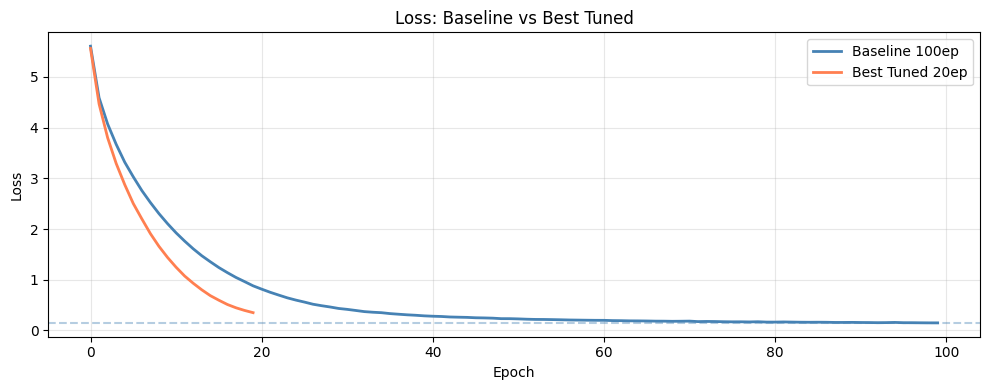

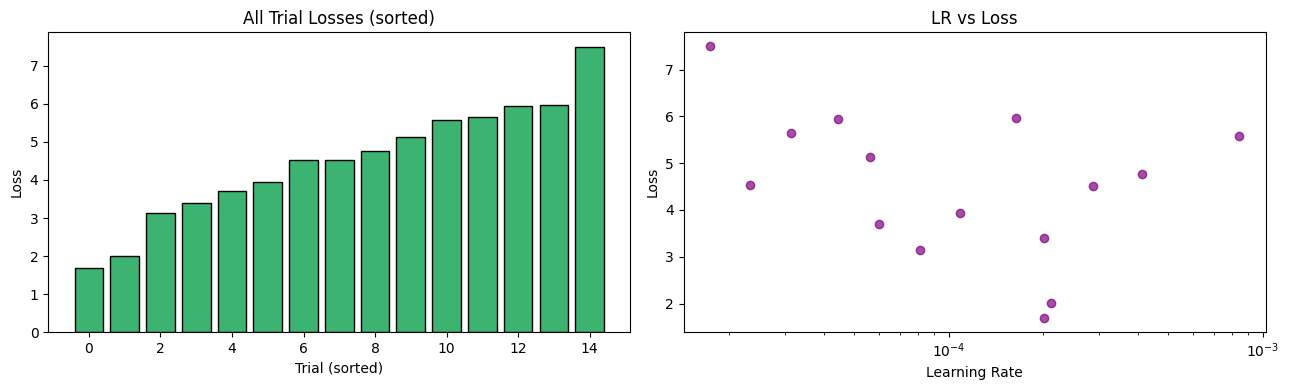

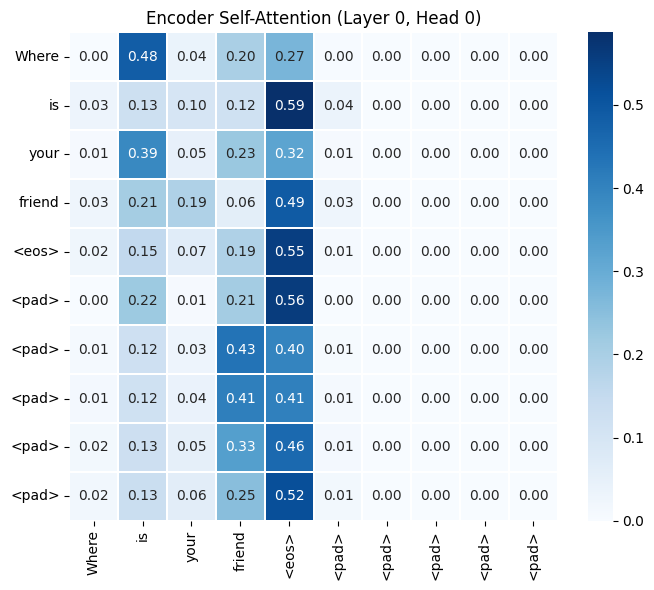

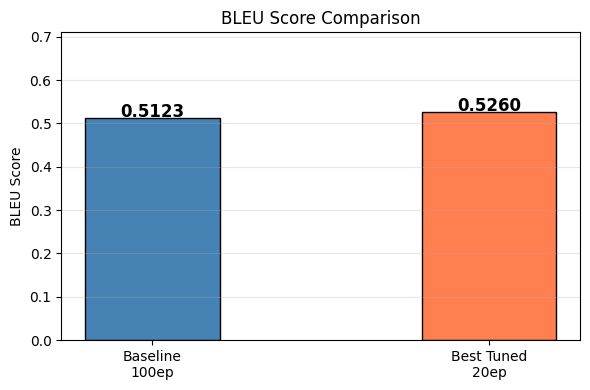

29420

In [13]:
# ============================================================
# CELL 6: Retrain best config, all plots, save best model
# ============================================================
final_config = {
    'd_model':        best_config['num_heads'] * best_config['d_model_per_head'],
    'num_heads':      best_config['num_heads'],
    'num_enc_layers': best_config['num_enc_layers'],
    'num_dec_layers': 3,
    'd_ff':           best_config['d_ff'],
    'dropout':        best_config['dropout'],
    'lr':             best_config['lr'],
    'batch_size':     best_config['batch_size'],
}
print("Final config:", json.dumps(final_config, indent=2))

best_model, best_losses, best_time = run_training(
    final_config, MAX_TUNE_EPOCHS, "Best")

best_bleu = compute_bleu(best_model, make_loader(64, shuffle=False))

print("\n" + "=" * 55)
print(f"  Baseline  Loss={baseline_losses[-1]:.4f}  BLEU={baseline_bleu:.4f}  {BASE_EPOCHS}ep")
print(f"  Tuned     Loss={best_losses[-1]:.4f}  BLEU={best_bleu:.4f}  {MAX_TUNE_EPOCHS}ep")
print("=" * 55)

# ── Plot 1: Loss comparison ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(baseline_losses, label='Baseline 100ep', color='steelblue', lw=2)
ax.plot(best_losses, label=f'Best Tuned {MAX_TUNE_EPOCHS}ep', color='coral', lw=2)
ax.axhline(baseline_losses[-1], ls='--', color='steelblue', alpha=0.4)
ax.set_title('Loss: Baseline vs Best Tuned')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('loss_comparison.png', dpi=120); plt.show()

# ── Plot 2: Optuna trial losses ───────────────────────────
trial_losses = [t.value for t in study.trials
                if t.value is not None]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(len(trial_losses)), sorted(trial_losses),
            color='mediumseagreen', edgecolor='black')
axes[0].set_xlabel('Trial (sorted)'); axes[0].set_ylabel('Loss')
axes[0].set_title('All Trial Losses (sorted)')

lr_vals   = [t.params['lr']   for t in study.trials if t.value is not None]
loss_vals = [t.value          for t in study.trials if t.value is not None]
axes[1].scatter(lr_vals, loss_vals, alpha=0.7, c='purple')
axes[1].set_xscale('log')
axes[1].set_xlabel('Learning Rate'); axes[1].set_ylabel('Loss')
axes[1].set_title('LR vs Loss')
plt.tight_layout(); plt.savefig('tuning_results.png', dpi=120); plt.show()

# ── Plot 3: Attention heatmap ─────────────────────────────
best_model.eval()
sample = torch.tensor([en_vocab.encode("Where is your friend")]).to(DEVICE)
dummy  = torch.tensor([[SOS_IDX] + [PAD_IDX] * (MAX_LEN - 1)]).to(DEVICE)
with torch.no_grad():
    _ = best_model(sample, dummy)
attn = best_model.enc[0].attn.last_attn[0, 0].cpu().numpy()
toks = ["Where","is","your","friend","<eos>","<pad>","<pad>","<pad>","<pad>","<pad>"]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(attn[:10, :10], xticklabels=toks, yticklabels=toks,
            cmap='Blues', annot=True, fmt='.2f', linewidths=0.3, ax=ax)
ax.set_title('Encoder Self-Attention (Layer 0, Head 0)')
plt.tight_layout(); plt.savefig('attention_heatmap.png', dpi=120); plt.show()

# ── Plot 4: BLEU comparison ───────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Baseline\n100ep', f'Best Tuned\n{MAX_TUNE_EPOCHS}ep'],
              [baseline_bleu, best_bleu],
              color=['steelblue', 'coral'], edgecolor='black', width=0.4)
for bar, val in zip(bars, [baseline_bleu, best_bleu]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('BLEU Score'); ax.set_title('BLEU Score Comparison')
ax.set_ylim(0, max(baseline_bleu, best_bleu) * 1.35)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('bleu_comparison.png', dpi=120); plt.show()

# ── Save best model ───────────────────────────────────────
torch.save(best_model.state_dict(), 'rollno_ass_4_best_model.pth')
with open('en_vocab.pkl', 'wb') as f: pickle.dump(en_vocab, f)
with open('hi_vocab.pkl', 'wb') as f: pickle.dump(hi_vocab, f)
with open('best_config.json', 'w') as f:
    json.dump({**final_config,
               'baseline_loss': baseline_losses[-1],
               'best_loss':     best_losses[-1],
               'baseline_bleu': baseline_bleu,
               'best_bleu':     best_bleu,
               'baseline_epochs': BASE_EPOCHS,
               'tuned_epochs':    MAX_TUNE_EPOCHS}, f, indent=2)


torch.cuda.empty_cache(); gc.collect()


In [14]:
# ============================================================
# CELL 7: Upload ONLY best model to HuggingFace Hub
# ============================================================
from huggingface_hub import HfApi, upload_file

HF_USERNAME = "Saumya3007"
REPO_ID     = f"{HF_USERNAME}/en-hi-transformer-tuned"

api = HfApi()
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)
print(f"✅ Repo ready: https://huggingface.co/{REPO_ID}")

# ── Build README without nested triple-quotes in f-string ─
config_str = json.dumps(final_config, indent=2)

readme_lines = [
    "---",
    "language: [en, hi]",
    "tags: [translation, pytorch, transformer, optuna]",
    "metrics: [bleu]",
    "---",
    "",
    "# English to Hindi Transformer (Optuna Optimized)",
    "",
    "Custom PyTorch Transformer tuned with **Optuna + SuccessiveHalving (ASHA)**.",
    "",
    "## Results",
    "",
    "| Model | Epochs | Loss | BLEU |",
    "|---|---|---|---|",
    f"| Baseline | {BASE_EPOCHS} | {baseline_losses[-1]:.4f} | {baseline_bleu:.4f} |",
    f"| **Best Tuned** | **{MAX_TUNE_EPOCHS}** | **{best_losses[-1]:.4f}** | **{best_bleu:.4f}** |",
    "",
    "## Best Hyperparameters",
    "",
    "```json",
    config_str,
    "```",
    "",
    "## Usage",
    "",
    "```python",
    "import torch, pickle, json",
    "from huggingface_hub import hf_hub_download",
    "",
    f'weights = hf_hub_download("{REPO_ID}", "rollno_ass_4_best_model.pth")',
    f'cfg     = json.load(open(hf_hub_download("{REPO_ID}", "best_config.json")))',
    "model   = Transformer(src_vocab, tgt_vocab, **{k: cfg[k] for k in",
    "          ['d_model','num_heads','num_enc_layers','num_dec_layers','d_ff','dropout']})",
    "model.load_state_dict(torch.load(weights, map_location='cpu'))",
    "model.eval()",
    "```",
]

readme = "\n".join(readme_lines)
with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

# ── Files to upload ───────────────────────────────────────
files = [
    ('rollno_ass_4_best_model.pth', 'rollno_ass_4_best_model.pth'),
    ('en_vocab.pkl',                'en_vocab.pkl'),
    ('hi_vocab.pkl',                'hi_vocab.pkl'),
    ('best_config.json',            'best_config.json'),
    ('README.md',                   'README.md'),
    ('loss_comparison.png',         'assets/loss_comparison.png'),
    ('bleu_comparison.png',         'assets/bleu_comparison.png'),
    ('attention_heatmap.png',       'assets/attention_heatmap.png'),
    ('tuning_results.png',          'assets/tuning_results.png'),
    ('baseline_loss_curve.png',     'assets/baseline_loss_curve.png'),
    ('eda_lengths.png',             'assets/eda_lengths.png'),
]

for local, remote in files:
    if os.path.exists(local):
        upload_file(
            path_or_fileobj = local,
            path_in_repo    = remote,
            repo_id         = REPO_ID,
            repo_type       = "model",
        )
        print(f"  ✅ Uploaded: {remote}")
    else:
        print(f"  ⚠️  Skipped (not found): {local}")

print(f"\n🎉 Done → https://huggingface.co/{REPO_ID}")
print(f"   BLEU: Baseline={baseline_bleu:.4f}  →  Best={best_bleu:.4f} in {MAX_TUNE_EPOCHS} epochs")
torch.cuda.empty_cache(); gc.collect()
{json.dumps(final_config, indent=2)}


✅ Repo ready: https://huggingface.co/Saumya3007/en-hi-transformer-tuned


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✅ Uploaded: rollno_ass_4_best_model.pth


Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

  ✅ Uploaded: en_vocab.pkl


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✅ Uploaded: hi_vocab.pkl
  ✅ Uploaded: best_config.json
  ✅ Uploaded: README.md
  ✅ Uploaded: assets/loss_comparison.png
  ✅ Uploaded: assets/bleu_comparison.png
  ✅ Uploaded: assets/attention_heatmap.png
  ✅ Uploaded: assets/tuning_results.png
  ✅ Uploaded: assets/baseline_loss_curve.png
  ✅ Uploaded: assets/eda_lengths.png

🎉 Done → https://huggingface.co/Saumya3007/en-hi-transformer-tuned
   BLEU: Baseline=0.5123  →  Best=0.5260 in 20 epochs


{'{\n  "d_model": 512,\n  "num_heads": 8,\n  "num_enc_layers": 4,\n  "num_dec_layers": 3,\n  "d_ff": 2048,\n  "dropout": 0.05109771787083142,\n  "lr": 0.00020147922100273766,\n  "batch_size": 128\n}'}